# Gameplan Notebook — Predicting Voter Turnout in Europe

**Course:** Machine Learning and Deep Learning (CBS, Spring 2026)
**Author:** Maria Bitner
**Companion to:** `gameplan.md`

---

This notebook is the **executable scaffold** for the final project. Every section corresponds to a section in `gameplan.md`. Each cell contains:

1. A **markdown header** explaining what the step does and *why*.
2. A **code stub** ready to run — most are skeletons you'll fill in as you go.

The structure mirrors the report template required by the course (Lecture-16 guidelines):
Introduction → Conceptual Framework → Methodology *(special focus)* → Results → Discussion → Ethics → Self-improvement.

> **Note:** the existing `marysia_data.ipynb` already contains target cleaning. This notebook re-loads from raw so the pipeline is end-to-end reproducible from a single file.


## 0. Setup & reproducibility

Imports, fixed seeds, plotting style. Everything downstream assumes this cell ran first.


In [3]:
# Core
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, time, json

# Modeling
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss,
    classification_report, confusion_matrix, roc_curve, precision_recall_curve
)

# Imbalance
# from imblearn.over_sampling import SMOTE, ADASYN   # pip install imbalanced-learn

# Deep learning
# import tensorflow as tf
# from tensorflow import keras

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

DATA_PATH = 'ESS11e04_1.csv'
print('Setup complete.')


Setup complete.


## 1. Introduction

### 1.1 Motivation
Voter turnout has been declining unevenly across Europe for decades. Predicting *who votes* matters for political parties, governments, NGOs, and academic political science. Most existing turnout work is logistic-regression-based; this project benchmarks modern ML and a small deep learning model against that classical baseline.

### 1.2 Research questions
- **RQ1 (predictive):** How accurately can voter turnout be predicted from individual-level survey responses across 30 European countries, and which model family performs best?
- **RQ2 (explanatory):** Which categories of features — socio-demographic, socio-economic, political attitudes, institutional trust, civic/political engagement, satisfaction, or media use — contribute most to predictive performance?
- **RQ3 (cross-national):** Does country information meaningfully improve prediction, and which countries are hardest to classify correctly?

### 1.3 Related work
To be populated with 5–8 citations from Google Scholar covering: (a) classical political-science models of turnout, (b) recent ML applications to voting/turnout, (c) ML methodology for survey data and class imbalance.


## 2. Conceptual Framework

Anchored in the **Civic Voluntarism Model** (Verba, Schlozman & Brady, 1995), extended with institutional trust and media exposure.

### 2.1 Refined feature taxonomy (7 categories)

| # | Category | ESS variables |
|---|---|---|
| 1 | Socio-demographic | `agea`, `gndr`, `cntry` |
| 2 | Socio-economic resources | `eduyrs`, `hinctnta` |
| 3 | Political interest & ideology | `polintr`, `lrscale`, `clsprty` |
| 4 | Institutional trust | `trstprl`, `trstplt`, `trstprt`, `trstlgl` |
| 5 | Civic & political engagement | `contplt`, `sgnptit`, `cptppola`, `psppsgva`, `psppipla` |
| 6 | Satisfaction with system | `stfdem`, `stfgov`, `stfeco` |
| 7 | Media & information | `nwspol`, `netusoft` |
| — | Survey weights *(not features)* | `pspwght`, `anweight` |


In [4]:
# Single source of truth for the feature taxonomy.
# Every later step references this dict.

FEATURE_GROUPS = {
    'socio_demographic':  ['agea', 'gndr', 'cntry'],
    'socio_economic':     ['eduyrs', 'hinctnta'],
    'political_interest': ['polintr', 'lrscale', 'clsprty'],
    'institutional_trust':['trstprl', 'trstplt', 'trstprt', 'trstlgl'],
    'civic_engagement':   ['contplt', 'sgnptit', 'cptppola', 'psppsgva', 'psppipla'],
    'satisfaction':       ['stfdem', 'stfgov', 'stfeco'],
    'media':              ['nwspol', 'netusoft'],
}

WEIGHTS = ['pspwght', 'anweight']   # never used as features
TARGET  = 'vote'

ALL_FEATURES = [v for grp in FEATURE_GROUPS.values() for v in grp]
USECOLS = ALL_FEATURES + WEIGHTS + [TARGET]

print(f'Total features: {len(ALL_FEATURES)} across {len(FEATURE_GROUPS)} categories.')


Total features: 22 across 7 categories.


## 3. Methodology *(special focus)*

### 3.1 Dataset description
- **Source:** European Social Survey, Round 11 (fieldwork 2023–2024).
- **N respondents:** 50,116. **N countries:** 30. **Selected columns:** 25 (24 features + target).


In [5]:
df_raw = pd.read_csv(DATA_PATH, usecols=USECOLS)
print(f'Shape: {df_raw.shape}')
print(f'Countries ({df_raw.cntry.nunique()}): {sorted(df_raw.cntry.unique())}')
df_raw.head()


Shape: (50116, 25)
Countries (30): ['AT', 'BE', 'BG', 'CH', 'CY', 'DE', 'EE', 'ES', 'FI', 'FR', 'GB', 'GR', 'HR', 'HU', 'IE', 'IL', 'IS', 'IT', 'LT', 'LV', 'ME', 'NL', 'NO', 'PL', 'PT', 'RS', 'SE', 'SI', 'SK', 'UA']


,cntry,pspwght,anweight,nwspol,netusoft,polintr,psppsgva,psppipla,cptppola,trstprl,...,sgnptit,clsprty,lrscale,stfeco,stfgov,stfdem,gndr,agea,eduyrs,hinctnta
0,AT,0.392891,0.130013,90,5,1,4,4,5,6,...,2,1,5,6,4,6,1,65,12,6
1,AT,0.325153,0.107598,90,5,2,3,3,2,6,...,1,1,0,2,5,7,2,21,14,1
2,AT,4.000023,1.323666,30,5,2,4,4,3,7,...,1,1,3,6,5,6,2,53,16,5
3,AT,0.176228,0.058316,15,1,3,2,2,3,5,...,2,2,5,4,4,6,2,78,14,2
4,AT,1.060940,0.351080,60,5,2,3,4,3,6,...,1,1,2,6,7,8,1,64,12,77


### 3.2 Exploratory Data Analysis (EDA)

Six EDA blocks. Each one will produce a figure that goes into the Word report.

1. Sample composition (country, age, gender, education).
2. Target distribution (overall + by country + by age band).
3. Feature distributions (raw, with sentinel-code prevalence flagged).
4. Bivariate associations (turnout rate by each ordinal feature).
5. Multicollinearity (Spearman heatmap).
6. Class-imbalance summary.


In [11]:
# 3.2.1 Sample composition — country participation map
# (Already in marysia_data.ipynb; copy that cell here when integrating.)

# 3.2.2 Target distribution — raw vs. cleaned
# (Already in marysia_data.ipynb; copy that cell here when integrating.)

# Sentinel-code summary table
# Quick utility to count how often each sentinel value appears per column.
def sentinel_summary(df, sentinels=(66, 77, 88, 99, 6666, 7777, 8888, 9999)):
    rows = []
    for col in df.columns:
        if col in [TARGET, 'cntry']:
            continue
        s = df[col]
        if not pd.api.types.is_numeric_dtype(s):
            continue
        for v in sentinels:
            n = (s == v).sum()
            if n > 0:
                rows.append({'variable': col, 'sentinel': v, 'count': int(n), 'pct': round(100*n/len(s), 2)})
    return pd.DataFrame(rows).sort_values(['variable', 'sentinel'])

sentinel_summary(df_raw).head(30)


,variable,sentinel,count,pct
29,agea,66,888,1.77
30,agea,77,582,1.16
31,agea,88,139,0.28
32,eduyrs,77,254,0.51
33,eduyrs,88,613,1.22
34,eduyrs,99,34,0.07
35,hinctnta,77,7277,14.52
36,hinctnta,88,3105,6.20
37,hinctnta,99,46,0.09
17,lrscale,77,2031,4.05


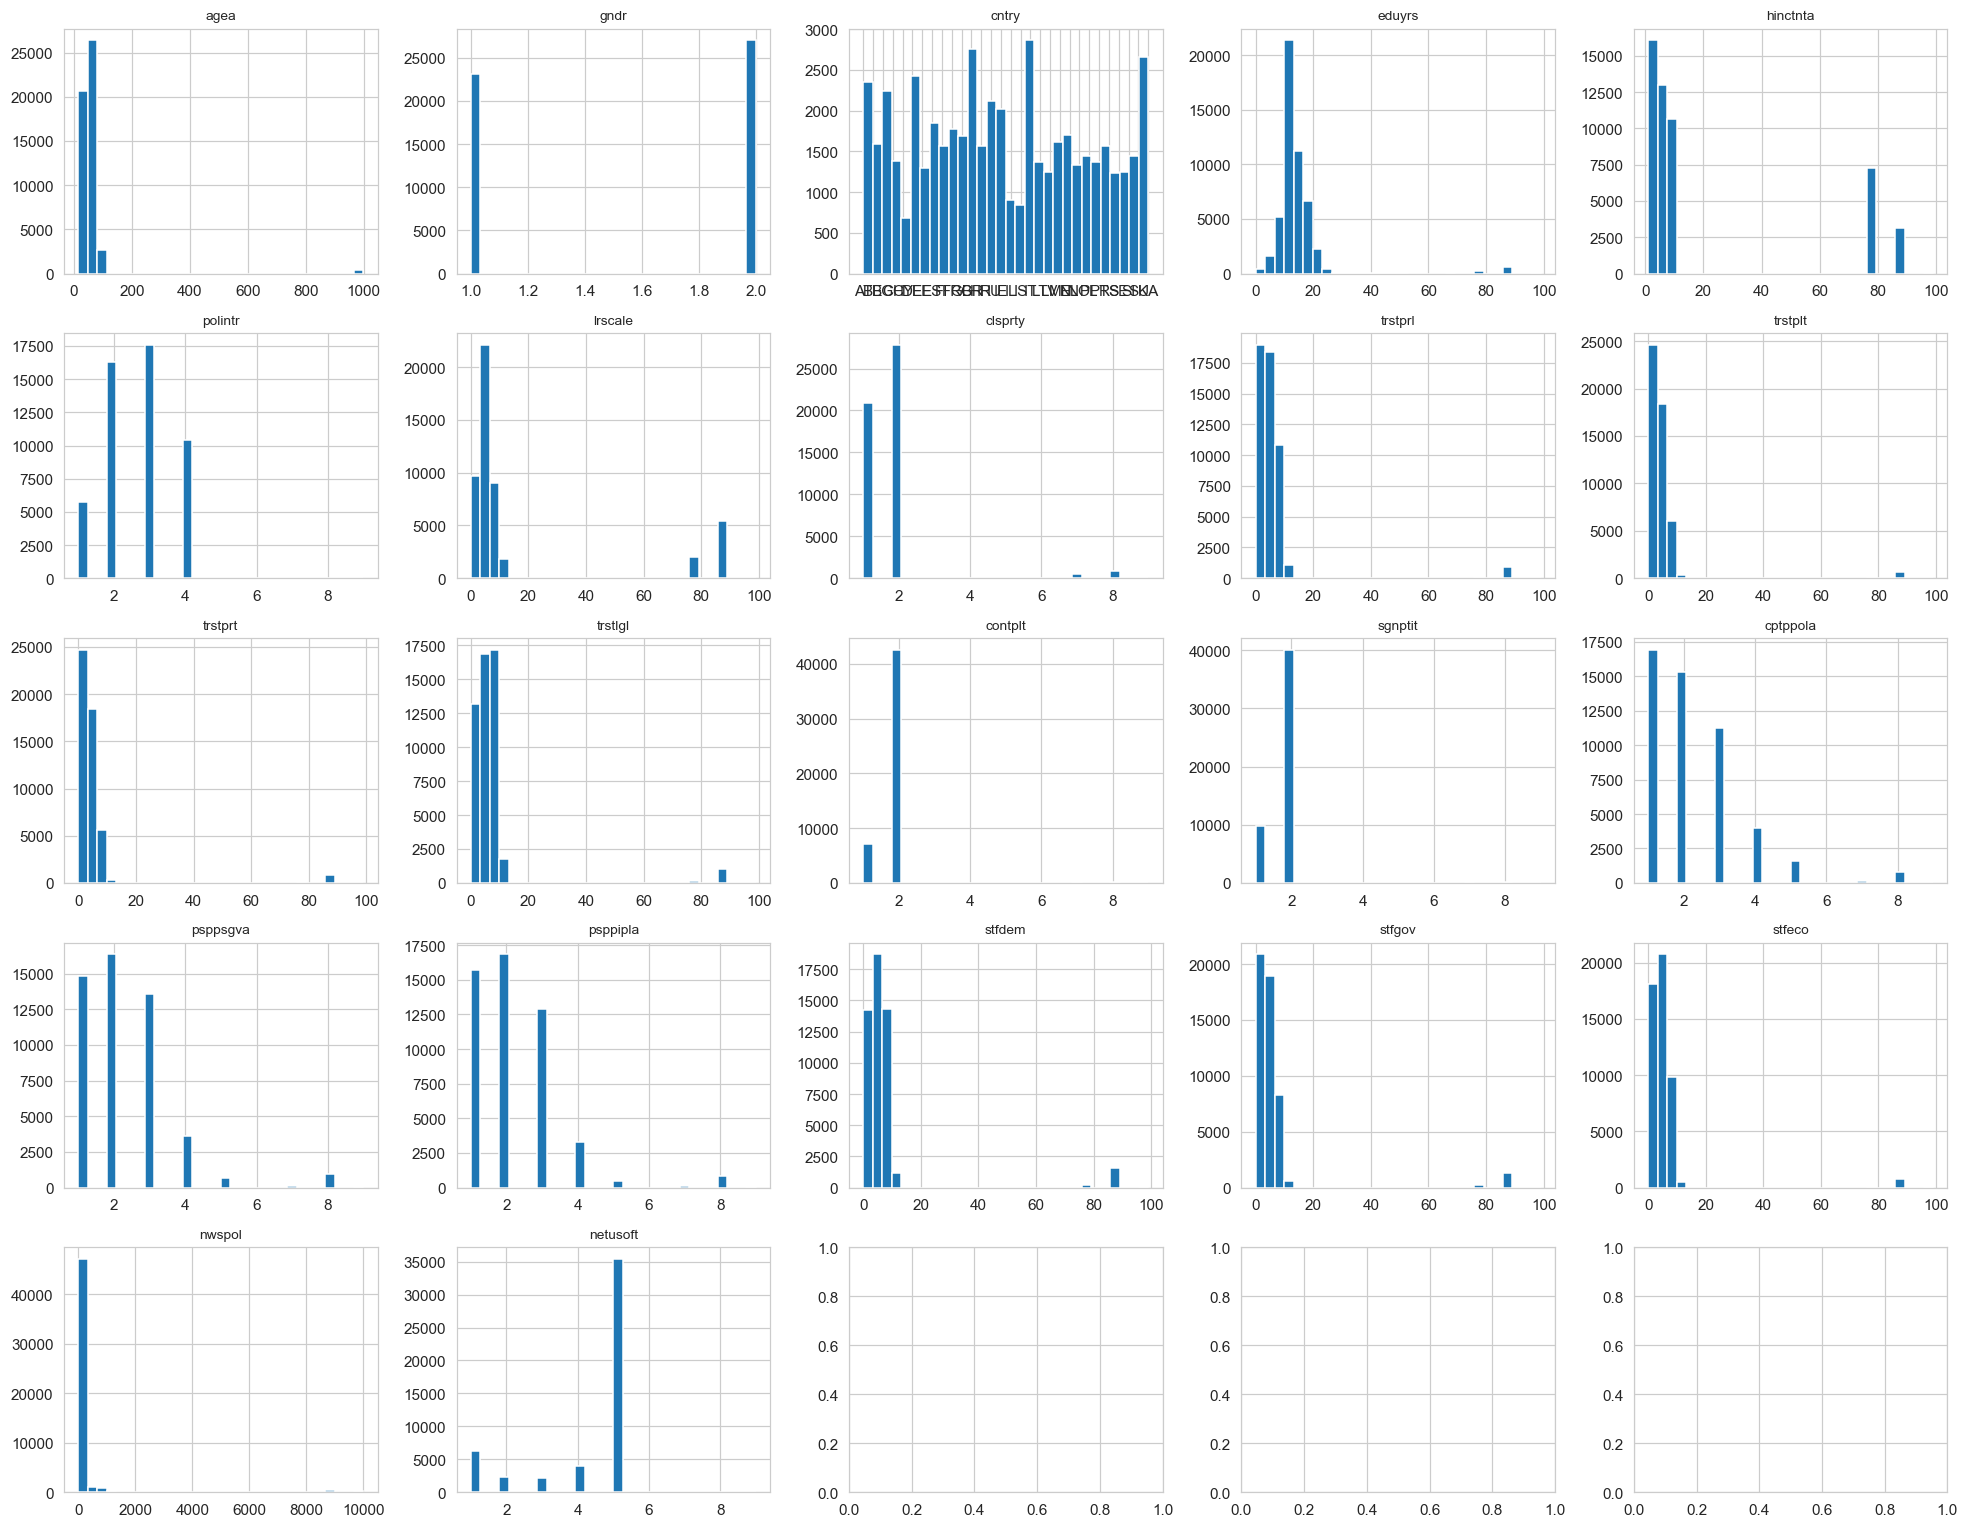

In [ ]:
# 3.2.3 Feature distributions — quick grid of histograms
fig, axes = plt.subplots(5, 5, figsize=(18, 14))
for ax, col in zip(axes.flat, ALL_FEATURES):
    df_raw[col].hist(ax=ax, bins=30)
    ax.set_title(col, fontsize=9)
plt.tight_layout()

# 3.2.4 Bivariate — turnout rate by each ordinal feature
# def turnout_by(df, col):
#     ... return groupby mean of binary target ...

# 3.2.5 Spearman correlation heatmap (numeric features only, AFTER cleaning)
# Use this to decide whether to compress the 4 trust variables into a single index.

# 3.2.6 Class imbalance — print value_counts after cleaning (next section)


### 3.3 Data preprocessing — variable by variable

This is the *core* of the methodology section. The goal: every variable has a documented, defensible cleaning rule.

**ESS sentinel-code conventions:**
- Long Likert / numeric (0–10, age, etc.):  `77` = Refusal, `88` = Don't know, `99` = No answer (sometimes also `66` = Not applicable; for time-in-minutes it's `5555/7777/8888/9999`).
- Short Likert (1–5, 1–4, binary):  `7` / `8` / `9` for the same three codes.
- Target (`vote`): `3` = Not eligible, `7/8/9` = non-response (already handled).

**Strategy:** replace sentinels with NaN, then impute (median for ordinal/numeric, mode for binary/categorical). Keep `_was_missing` flags for variables with non-trivial missing rate.


In [7]:
# 3.3.1 — Per-variable sentinel code map
SENTINELS = {
    'agea':     [999],
    'gndr':     [9],
    'eduyrs':   [77, 88, 99],
    'hinctnta': [77, 88, 99],
    'polintr':  [7, 8, 9],
    'lrscale':  [77, 88, 99],
    'clsprty':  [7, 8, 9],
    'trstprl':  [77, 88, 99],
    'trstplt':  [77, 88, 99],
    'trstprt':  [77, 88, 99],
    'trstlgl':  [77, 88, 99],
    'contplt':  [7, 8, 9],
    'sgnptit':  [7, 8, 9],
    'cptppola': [7, 8, 9],
    'psppsgva': [7, 8, 9],
    'psppipla': [7, 8, 9],
    'stfdem':   [77, 88, 99],
    'stfgov':   [77, 88, 99],
    'stfeco':   [77, 88, 99],
    'nwspol':   [6666, 7777, 8888, 9999],
    'netusoft': [7, 8, 9],
}

# Reverse-coded: lower raw = more interest. Recode so higher = more interest.
REVERSE_CODE = ['polintr']

# Binary recodes: ESS uses 1=yes, 2=no -> map to 1/0
BINARY_RECODE = ['gndr', 'clsprty', 'contplt', 'sgnptit']

print('Sentinel rules defined for', len(SENTINELS), 'variables.')


Sentinel rules defined for 21 variables.


In [8]:
# 3.3.2 — Cleaner

def clean_ess(df_in, sentinels=SENTINELS, reverse=REVERSE_CODE, binary=BINARY_RECODE):
    df = df_in.copy()

    # 1) Target — drop ineligible and non-response, recode 1/2 -> 1/0
    df = df[df[TARGET].isin([1, 2])].copy()
    df[TARGET] = (df[TARGET] == 1).astype(int)

    # 2) Replace sentinels with NaN
    for col, codes in sentinels.items():
        df[col] = df[col].replace(codes, np.nan)

    # 3) Reverse-code where higher should mean "more"
    for col in reverse:
        if col in df.columns:
            mx = df[col].max(skipna=True)
            df[col] = mx + 1 - df[col]

    # 4) Recode 1/2 -> 1/0 binaries
    for col in binary:
        if col in df.columns:
            df[col] = df[col].map({1: 1, 2: 0})

    # 5) Imputation
    binary_set = set(binary)
    for col in df.columns:
        if col in [TARGET, 'cntry'] + WEIGHTS:
            continue
        if df[col].isna().any():
            if col in binary_set:
                df[col] = df[col].fillna(df[col].mode().iloc[0])
            else:
                df[col] = df[col].fillna(df[col].median())

    return df.reset_index(drop=True)

# df_clean = clean_ess(df_raw)
# print(df_clean.shape)
# print(df_clean.isna().sum().sum(), 'NaNs remaining')


### 3.5 Feature engineering

Two parallel feature sets:
- **(A) Raw** — all 24 cleaned features.
- **(B) Composite** — replace correlated groups with mean indices.


In [9]:
def add_engineered_features(df):
    out = df.copy()
    out['trust_index']        = out[['trstprl', 'trstplt', 'trstprt', 'trstlgl']].mean(axis=1)
    out['efficacy_index']     = out[['cptppola', 'psppsgva', 'psppipla']].mean(axis=1)
    out['satisfaction_index'] = out[['stfdem', 'stfgov', 'stfeco']].mean(axis=1)
    out['lr_extreme']         = (out['lrscale'] - 5).abs()
    out['age_group']          = pd.cut(out['agea'], bins=[0, 24, 34, 49, 64, 120],
                                       labels=['18-24', '25-34', '35-49', '50-64', '65+'])
    return out

def build_feature_matrix_A(df):
    # Raw features (drop weights and target)
    X = df.drop(columns=[TARGET] + WEIGHTS + ['cntry']).copy()
    X = pd.get_dummies(df[['cntry']], prefix='c', drop_first=True).join(X)
    return X

def build_feature_matrix_B(df):
    # Composite indices replace their components
    df2 = add_engineered_features(df)
    drop_components = ['trstprl', 'trstplt', 'trstprt', 'trstlgl',
                       'cptppola', 'psppsgva', 'psppipla',
                       'stfdem', 'stfgov', 'stfeco', 'age_group']
    X = df2.drop(columns=[TARGET] + WEIGHTS + ['cntry'] + drop_components).copy()
    X = pd.get_dummies(df2[['cntry']], prefix='c', drop_first=True).join(X)
    return X


### 3.6 Train / validation / test split

Stratified 70 / 15 / 15 to preserve the ~78/22 class ratio in every fold.


In [10]:
def stratified_split(X, y, val=0.15, test=0.15, seed=RANDOM_STATE):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=test, stratify=y, random_state=seed)
    val_rel = val / (1 - test)
    X_tr, X_va, y_tr, y_va = train_test_split(X_tr, y_tr, test_size=val_rel, stratify=y_tr, random_state=seed)
    return X_tr, X_va, X_te, y_tr, y_va, y_te


### 3.7 Class imbalance

Compare:
1. `class_weight='balanced'` (default we'll try first)
2. SMOTE (Lecture 7, [J01])
3. ADASYN ([J02])

**Critical:** apply resampling *only* to the training fold inside CV. Never on val/test.


In [ ]:
# from imblearn.over_sampling import SMOTE, ADASYN
# smote  = SMOTE(random_state=RANDOM_STATE)
# adasyn = ADASYN(random_state=RANDOM_STATE)
# X_tr_smote, y_tr_smote = smote.fit_resample(X_tr, y_tr)
# Print the new class balance.


### 3.8 Models

| Role | Model | Library |
|---|---|---|
| Baseline | Logistic Regression (L2) | scikit-learn |
| Primary 1 | Random Forest | scikit-learn |
| Primary 2 | Gradient Boosting | sklearn / xgboost |
| Primary 3 | Feed-Forward Neural Network | Keras / TensorFlow |


#### 3.8.1 Baseline — Logistic Regression

In [ ]:
def train_logreg(X_tr, y_tr, X_va, y_va):
    pipe = Pipeline([
        ('scaler', StandardScaler(with_mean=False)),
        ('clf', LogisticRegression(max_iter=2000, class_weight='balanced',
                                   solver='liblinear', random_state=RANDOM_STATE)),
    ])
    grid = {'clf__C': [0.01, 0.1, 1, 10], 'clf__penalty': ['l1', 'l2']}
    gs = GridSearchCV(pipe, grid, scoring='average_precision', cv=5, n_jobs=-1)
    t0 = time.time()
    gs.fit(X_tr, y_tr)
    runtime = time.time() - t0
    return gs.best_estimator_, gs.best_params_, runtime


#### 3.8.2 Random Forest

In [ ]:
def train_rf(X_tr, y_tr, X_va, y_va):
    rf = RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
    grid = {
        'n_estimators': [200, 500],
        'max_depth':    [None, 10, 20],
        'min_samples_leaf': [1, 5, 10],
    }
    gs = RandomizedSearchCV(rf, grid, n_iter=10, scoring='average_precision',
                            cv=5, n_jobs=-1, random_state=RANDOM_STATE)
    t0 = time.time()
    gs.fit(X_tr, y_tr)
    runtime = time.time() - t0
    return gs.best_estimator_, gs.best_params_, runtime


#### 3.8.3 Gradient Boosting

In [ ]:
def train_gbm(X_tr, y_tr, X_va, y_va):
    gbm = GradientBoostingClassifier(random_state=RANDOM_STATE)
    grid = {
        'n_estimators': [200, 400],
        'learning_rate': [0.05, 0.1],
        'max_depth':     [3, 5],
        'subsample':     [0.8, 1.0],
    }
    gs = RandomizedSearchCV(gbm, grid, n_iter=8, scoring='average_precision',
                            cv=5, n_jobs=-1, random_state=RANDOM_STATE)
    t0 = time.time()
    gs.fit(X_tr, y_tr)
    runtime = time.time() - t0
    return gs.best_estimator_, gs.best_params_, runtime


#### 3.8.4 Feed-Forward Neural Network (Keras)

A small 2–3 hidden layer network. Dropout + early stopping. The architecture is intentionally modest — tabular data of this size rarely benefits from deeper nets, and the project guidelines warn against complex models as primary.


In [ ]:
# import tensorflow as tf
# from tensorflow import keras
# from tensorflow.keras import layers
#
# def build_ffnn(input_dim, hidden=(128, 64), dropout=0.3, lr=1e-3):
#     model = keras.Sequential()
#     model.add(layers.Input(shape=(input_dim,)))
#     for h in hidden:
#         model.add(layers.Dense(h, activation='relu'))
#         model.add(layers.BatchNormalization())
#         model.add(layers.Dropout(dropout))
#     model.add(layers.Dense(1, activation='sigmoid'))
#     model.compile(optimizer=keras.optimizers.Adam(lr),
#                   loss='binary_crossentropy',
#                   metrics=[keras.metrics.AUC(curve='PR', name='pr_auc'),
#                            keras.metrics.AUC(name='roc_auc')])
#     return model
#
# def train_ffnn(X_tr, y_tr, X_va, y_va):
#     scaler = StandardScaler(with_mean=False)
#     X_tr_s = scaler.fit_transform(X_tr)
#     X_va_s = scaler.transform(X_va)
#
#     # Class weights instead of resampling, by default
#     pos = y_tr.sum(); neg = len(y_tr) - pos
#     cw = {0: len(y_tr)/(2*neg), 1: len(y_tr)/(2*pos)}
#
#     model = build_ffnn(X_tr_s.shape[1])
#     es = keras.callbacks.EarlyStopping(monitor='val_pr_auc', mode='max',
#                                        patience=10, restore_best_weights=True)
#     t0 = time.time()
#     hist = model.fit(X_tr_s, y_tr, validation_data=(X_va_s, y_va),
#                      epochs=100, batch_size=256, class_weight=cw,
#                      callbacks=[es], verbose=0)
#     runtime = time.time() - t0
#     return model, scaler, hist, runtime


### 3.10 Evaluation metrics

Reported on the **held-out test set**:
- Confusion matrix
- Accuracy, Precision, Recall, F1 (per class — focus on the minority "did not vote")
- ROC-AUC, **PR-AUC** (primary metric under imbalance)
- Brier score, calibration plot


In [ ]:
def evaluate(model, X_te, y_te, name='model'):
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X_te)[:, 1]
    else:
        proba = model.predict(X_te).ravel()
    pred = (proba >= 0.5).astype(int)

    out = {
        'model': name,
        'accuracy':  accuracy_score(y_te, pred),
        'precision': precision_score(y_te, pred, pos_label=0),   # minority class focus
        'recall':    recall_score(y_te, pred, pos_label=0),
        'f1':        f1_score(y_te, pred, pos_label=0),
        'roc_auc':   roc_auc_score(y_te, proba),
        'pr_auc':    average_precision_score(y_te, proba),
        'brier':     brier_score_loss(y_te, proba),
    }
    print(json.dumps(out, indent=2))
    print(classification_report(y_te, pred, target_names=['did_not_vote', 'voted']))
    return out, proba, pred


### 3.11 Model complexity & runtime

For each model record: parameters/depth, training wall-clock, inference time per sample, model size (KB).

In [ ]:
def complexity_report(model, X_te, name='model', train_seconds=None):
    import sys, pickle
    info = {'model': name, 'train_seconds': train_seconds}
    info['model_size_kb'] = round(sys.getsizeof(pickle.dumps(model)) / 1024, 1)
    t0 = time.time()
    if hasattr(model, 'predict_proba'):
        _ = model.predict_proba(X_te[:1000])
    else:
        _ = model.predict(X_te[:1000])
    info['inference_us_per_sample'] = round((time.time() - t0) * 1e6 / 1000, 2)
    return info


### 3.12 Feature importance & interpretability

- LR: standardised coefficients with 95% CIs.
- Tree models: Gini importance + **permutation importance** on the test set.
- FFNN: SHAP (DeepExplainer or KernelExplainer).
- **Category-level importance:** sum permutation importances within each of the 7 feature categories — this directly answers RQ2.
- **Country-level error analysis:** per-country recall — answers RQ3.


In [ ]:
# from sklearn.inspection import permutation_importance
# import shap

# def category_importance(perm_imp_series, feature_groups=FEATURE_GROUPS):
#     '''Sum permutation importances within each feature group.'''
#     out = {}
#     for cat, vars_ in feature_groups.items():
#         out[cat] = perm_imp_series.reindex(vars_, fill_value=0).sum()
#     return pd.Series(out).sort_values(ascending=False)

# def per_country_recall(model, X_te, y_te, cntry_te):
#     proba = model.predict_proba(X_te)[:, 1]
#     pred = (proba >= 0.5).astype(int)
#     return (pd.DataFrame({'cntry': cntry_te, 'y': y_te, 'pred': pred})
#               .groupby('cntry')
#               .apply(lambda g: recall_score(g.y, g.pred, pos_label=0))
#               .sort_values())


### 3.13 Overfitting / underfitting checks

- Learning curves (train vs. val score as N grows).
- Validation curves (score vs. key hyperparameter).
- For the FFNN: train-loss vs. val-loss over epochs; trigger early stopping on `val_pr_auc`.


In [ ]:
# from sklearn.model_selection import learning_curve, validation_curve
# Fill in once the best-tuned models exist.


## 4. Results

For each model: key findings, actionable insights, practical outcomes.

Planned tables / figures:
- **Table 1.** Test-set metric comparison (4 models).
- **Table 2.** Runtime / model-complexity comparison.
- **Figure 1.** ROC + PR curves overlaid.
- **Figure 2.** Category-level permutation importance bar chart.
- **Figure 3.** SHAP summary plot for the best model.
- **Figure 4.** Confusion matrices side by side.
- **Figure 5.** Per-country recall heatmap.


In [ ]:
# Results aggregation skeleton.
# results = []
# for name, m in [('LogReg', lr_model), ('RF', rf_model), ('GBM', gbm_model), ('FFNN', ffnn_model)]:
#     row, _, _ = evaluate(m, X_test, y_test, name=name)
#     results.append(row)
# results_df = pd.DataFrame(results)
# results_df


## 5. Ethical Considerations

- **Survey privacy** — ESS is anonymised, but turnout prediction enables micro-targeting. Discuss dual-use risk.
- **Algorithmic fairness** — check whether model errors are systematically larger for certain age groups, genders, or countries (disparate impact). Report per-group recall.
- **Sample bias** — country quotas mean pooled data are not uniformly representative of "Europe". Use weights for descriptive stats; flag as a limitation.
- **Causal disclaimer** — prediction ≠ causation. Don't claim e.g. low trust *causes* abstention.
- **AI alignment / dual use** — note (Lecture 14) the misuse risk by political operatives.


## 6. Discussion

- **RQ1 answer** — direct numerical comparison.
- **RQ2 answer** — category-level importance ranking.
- **RQ3 answer** — does `cntry` add signal? Which countries are hardest?
- **Limitations**
  - Cross-sectional data — no temporal modelling.
  - Self-reported turnout overstates real turnout by 10–15 pp (well-documented response bias).
  - 30 countries pooled hides national heterogeneity.
  - No regional (urban/rural) or political-system features (compulsory voting, electoral rules).


## 7. Conclusion & Future Work

- One-paragraph recap of the strongest finding.
- **Future work:** multi-level model with country random effects; cross-round comparison; macro-level features (turnout history, electoral system, GDP); benchmark a TabNet / FT-Transformer (post-course).

## 8. References (APA 7) — to be populated

- Verba, Schlozman & Brady (1995) — *Voice and Equality*.
- Géron (2022) — *Hands-On ML with Scikit-Learn, Keras, and TensorFlow*, 3rd ed.
- Chawla et al. (2002) — SMOTE [J01].
- He et al. (2008) — ADASYN [J02].
- ESS ERIC (2024) — ESS Round 11 documentation.


## 9. Self-improvement & process notes

### What's already done
- Variable selection across 7 conceptual groups.
- Country-participation choropleth.
- Target cleaning (`vote` 0/1).
- Two presentation tables (`table_vote_raw.png`, `table_vote_binary.png`).

### Next steps in order
1. Lock the variable list (§2).
2. Run the per-variable cleaner (§3.3).
3. Run the EDA suite, save figures (§3.2).
4. Build feature sets A and B (§3.5).
5. Train baseline LR end-to-end.
6. Add RF, then GBM, then FFNN — each must beat the previous PR-AUC by enough to justify its complexity.
7. Run feature-importance & SHAP analyses.
8. Write Results / Discussion / Ethics in Word.

### Pitfalls to avoid
- Treating ESS sentinel codes as real numbers.
- Applying SMOTE to the validation/test set.
- Reporting accuracy as the headline metric.
- Using survey weights as features.
- Cross-country pooling without `cntry` as a feature.

### Oral-exam prep
- Bias-variance, PR-AUC vs. ROC-AUC under imbalance, early stopping, dropout — be ready to explain all four.
- Justify FFNN architecture, SMOTE-vs-class-weights trade-off.
- One slide each for: RQ, methodology, best model + headline number, top 3 features, ethical caveat.

---

**End of gameplan notebook.**
